In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as ticker



In [10]:

df = pd.read_csv("panel_long_quarterly_with_acc_ca.csv")

df.head()

,country,date,variable,value
0,AT,2000Q1,spread,0.2431204278812968
1,AT,2000Q2,spread,0.2899663299663269
2,AT,2000Q3,spread,0.3221471359558308
3,AT,2000Q4,spread,0.3105314878104375
4,AT,2001Q1,spread,0.3196303030303031


In [5]:
df.columns

Index(['country', 'date', 'variable', 'value'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9518 entries, 0 to 9517
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   country   9518 non-null   object
 1   date      9518 non-null   object
 2   variable  9518 non-null   object
 3   value     9518 non-null   object
dtypes: object(4)
memory usage: 297.6+ KB


In [11]:
df["date"] = pd.PeriodIndex(df["date"], freq="Q")

In [12]:
df["variable"].unique()

array(['spread', 'yield_10y', 'debt_gdp', 'gdp_growth', 'reer',
       'reer_change', 'ca_gdp', 'acc_ca_gdp'], dtype=object)

In [13]:
df.groupby("variable")["value"].describe()

,count,unique,top,freq
variable,,,,
acc_ca_gdp,1159,1148,n.a.,12
ca_gdp,1159,1159,0.0136153510263074,1
debt_gdp,1200,745,67.2,8
gdp_growth,1200,1189,n.a.,12
reer,1200,1058,99.51,4
reer_change,1200,1189,n.a.,12
spread,1200,1087,0.0,100
yield_10y,1200,1043,3.64,5


For economic reasons we only work with data between 2004 and 2024

In [14]:
df = df[(df["date"] >= "2004Q1") & (df["date"] <= "2024Q4")]

In [15]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst rows:")
display(df.head())

Shape: (8064, 4)

Columns:
Index(['country', 'date', 'variable', 'value'], dtype='object')

Data types:
country            object
date        period[Q-DEC]
variable           object
value              object
dtype: object

First rows:


,country,date,variable,value
16,AT,2004Q1,spread,0.11558978605935
17,AT,2004Q2,spread,0.1219797979798
18,AT,2004Q3,spread,0.0725878787878766
19,AT,2004Q4,spread,0.0648199134199125
20,AT,2005Q1,spread,0.0029492063492067


In [17]:
duplicates = df.duplicated(subset=["country","date","variable"])

print("Number of duplicates:", duplicates.sum())

df[duplicates].head()

Number of duplicates: 0


,country,date,variable,value


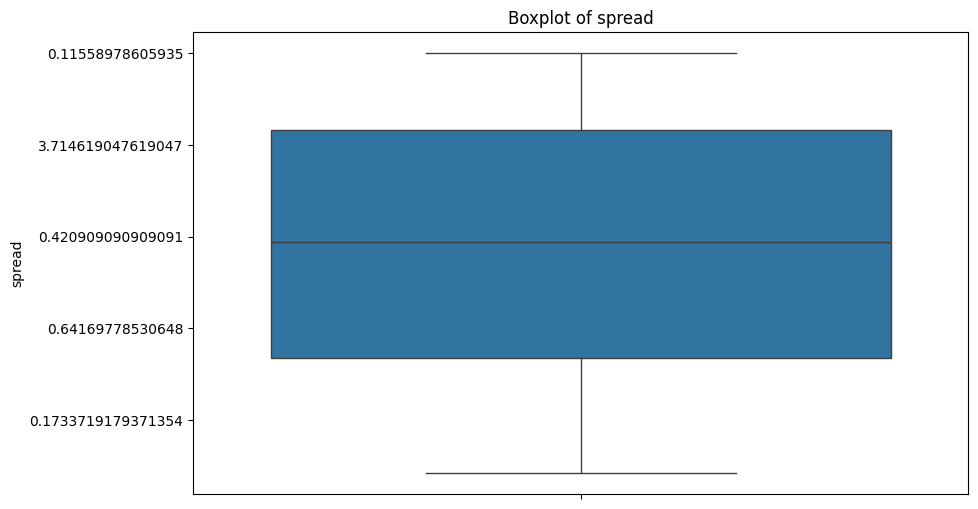

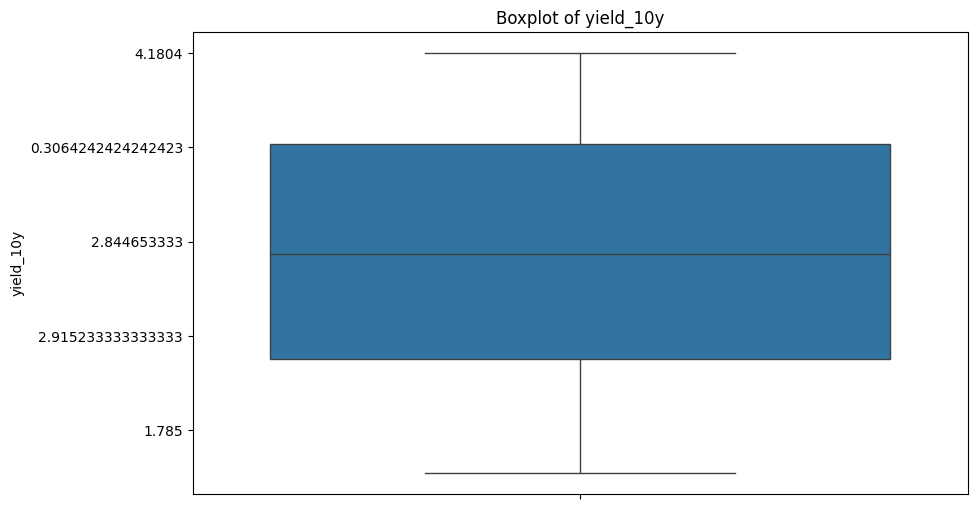

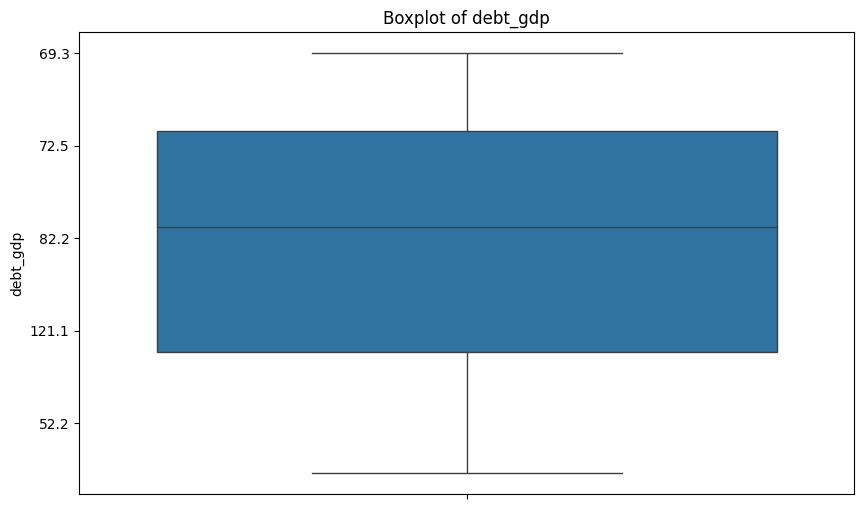

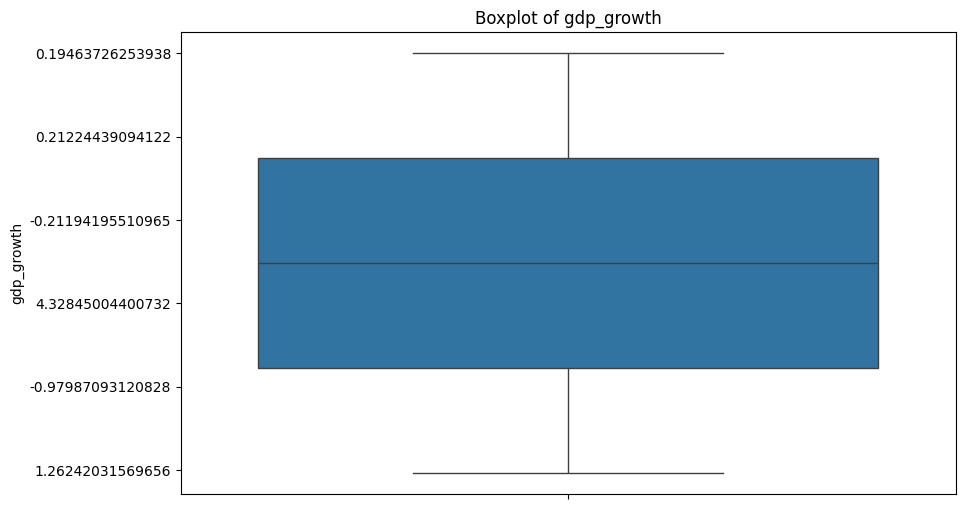

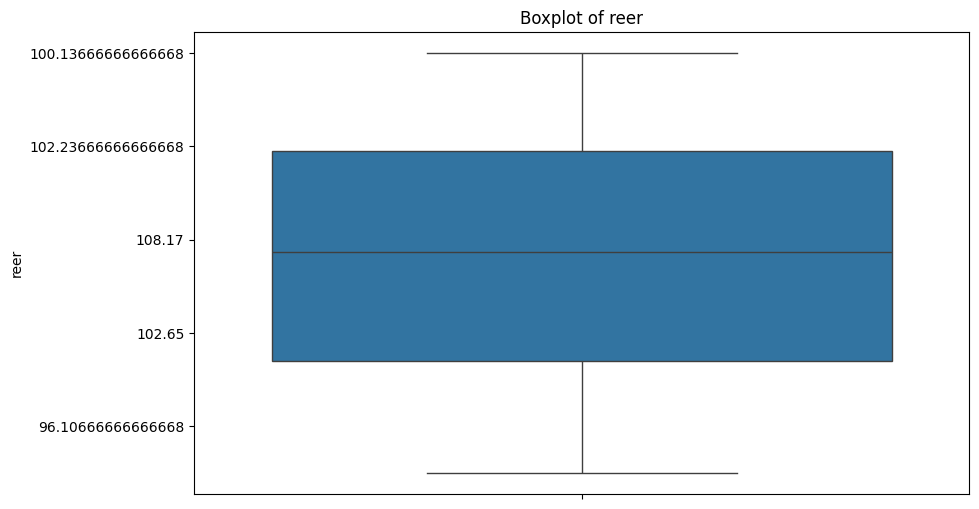

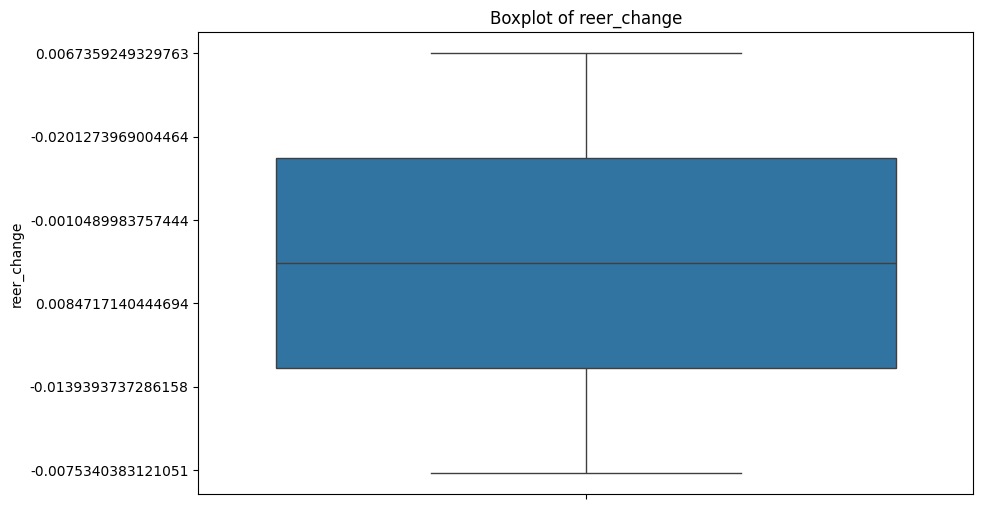

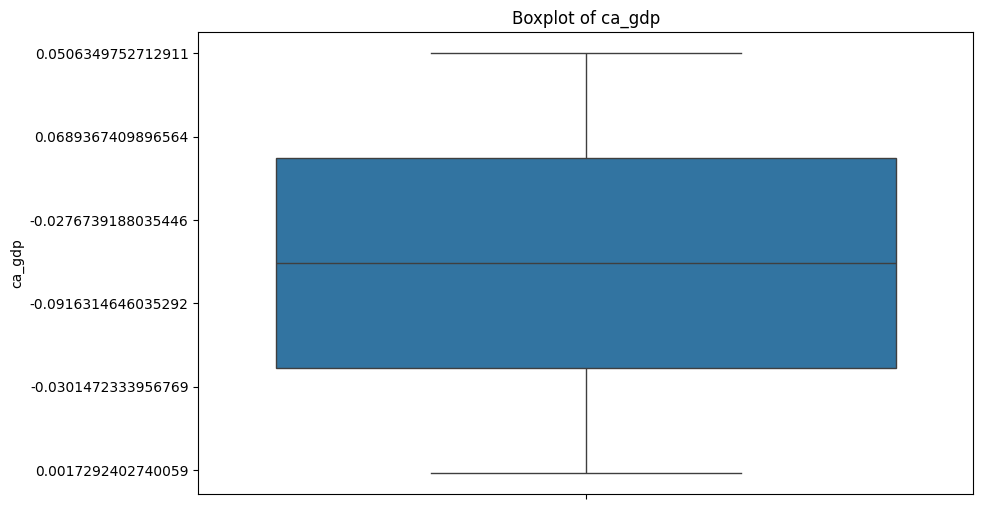

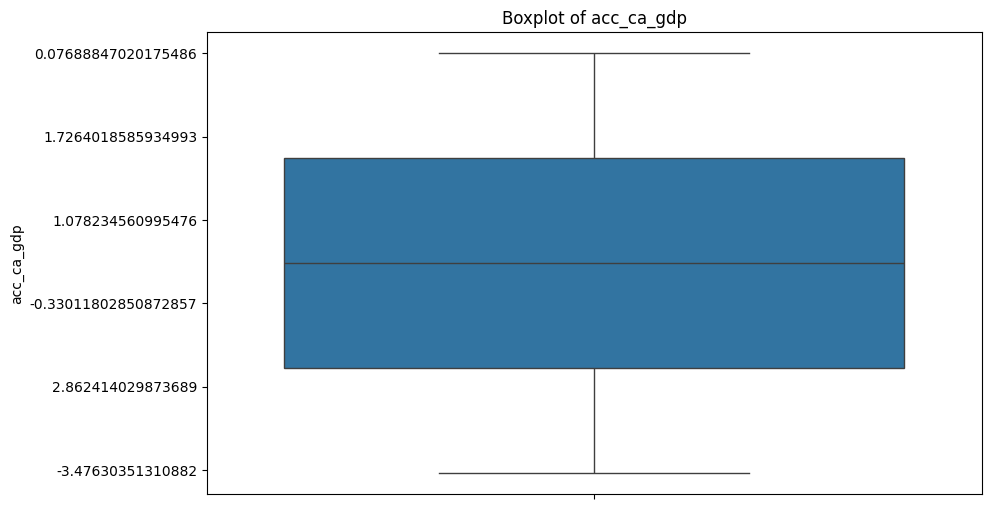

In [29]:


variables = df["variable"].unique()

for var in variables:

    plt.figure(figsize=(10,6))

    ax = sns.boxplot(
        data=df[df["variable"] == var],
        y="value"
    )

    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

    plt.title(f"Boxplot of {var}")
    plt.ylabel(var)

    plt.show()

In [14]:
df["value"] = pd.to_numeric(df["value"], errors="coerce")

C:\Users\robin\AppData\Local\Temp\ipykernel_19288\3107464877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = pd.to_numeric(df["value"], errors="coerce")


In [15]:
desc_stats = df.groupby("variable")["value"].describe()
desc_stats

,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
acc_ca_gdp,1008.0,0.077202,2.402638,-6.301103,-1.131266,0.180314,1.362984,5.708838
ca_gdp,1008.0,0.011537,0.077190,-0.780998,-0.021008,0.009471,0.053052,0.368320
debt_gdp,1008.0,84.230258,39.904087,6.800000,59.325000,79.200000,108.225000,212.900000
gdp_growth,1008.0,0.354597,2.291164,-19.589783,-0.095461,0.390093,0.873206,20.687062
reer,1008.0,102.098859,4.975396,93.470000,98.863333,100.626667,103.992500,129.960000
reer_change,1008.0,-0.000601,0.010913,-0.048695,-0.007127,-0.000129,0.006684,0.040659
spread,1008.0,1.047661,2.190491,-1.241020,0.157675,0.398537,1.023534,23.979498
yield_10y,1008.0,2.867751,2.556046,-0.613512,0.930000,2.920000,4.040000,25.400000


In [16]:
df_wide = df.pivot_table(
    index=["country","date"],
    columns="variable",
    values="value"
).reset_index()

In [17]:
corr = df_wide.drop(columns=["country","date"]).corr()
corr

variable,acc_ca_gdp,ca_gdp,debt_gdp,gdp_growth,reer,reer_change,spread,yield_10y
variable,,,,,,,,
acc_ca_gdp,1.000000,0.439455,-0.706165,0.025853,-0.256570,0.038704,-0.525849,-0.468611
ca_gdp,0.439455,1.000000,-0.278856,0.080014,-0.272593,-0.018193,-0.173960,-0.237402
debt_gdp,-0.706165,-0.278856,1.000000,-0.043216,-0.018049,-0.047014,0.511324,0.254280
gdp_growth,0.025853,0.080014,-0.043216,1.000000,-0.056940,-0.097307,-0.136826,-0.138669
reer,-0.256570,-0.272593,-0.018049,-0.056940,1.000000,0.089784,0.225347,0.504901
reer_change,0.038704,-0.018193,-0.047014,-0.097307,0.089784,1.000000,-0.067070,-0.015826
spread,-0.525849,-0.173960,0.511324,-0.136826,0.225347,-0.067070,1.000000,0.792357
yield_10y,-0.468611,-0.237402,0.254280,-0.138669,0.504901,-0.015826,0.792357,1.000000


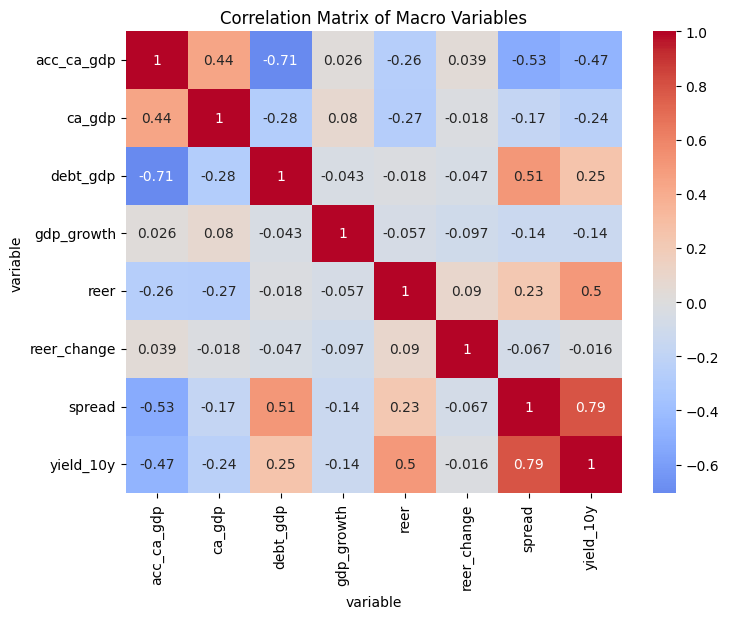

In [18]:


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Matrix of Macro Variables")
plt.show()

The correlation matrix reveals several economically meaningful relationships between sovereign risk, fiscal fundamentals, and external balances. Sovereign spreads are positively correlated with government debt-to-GDP ratios (0.51), suggesting that higher public indebtedness increases perceived default risk and leads investors to demand higher risk premia on government bonds. In addition, accumulated current account balances are strongly negatively correlated with public debt (−0.71). This relationship reflects the intertemporal nature of external imbalances: countries that persistently run current account deficits tend to accumulate external liabilities, which are often mirrored in higher levels of public or total debt. Finally, sovereign spreads are negatively correlated with accumulated current account balances (−0.53). Countries with weaker external positions and sustained current account deficits are typically more dependent on external financing and therefore face higher sovereign risk premia. These correlations are broadly consistent with theoretical and empirical literature linking fiscal sustainability and external imbalances to sovereign borrowing costs.

In [26]:
summary = df.groupby("variable")["value"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max",
    observations="count"
)

In [ ]:


with PdfPages("data_out/plots_pdf/descriptive_statistics_04_24.pdf") as pdf:

    fig, ax = plt.subplots(figsize=(10,4))
    ax.axis("tight")
    ax.axis("off")

    table = ax.table(
        cellText=summary.round(3).values,
        colLabels=summary.columns,
        rowLabels=summary.index,
        loc="center"
    )

    table.scale(1,1.5)
    plt.title("Descriptive Statistics (2004Q1–2024Q4)")

    pdf.savefig()
    plt.close()

In [ ]:
#clustering spreads

df_spread = df[df["variable"] == "spread"].copy()
spread_wide = df_spread.pivot_table(
    index="country",
    columns="date",
    values="value"
)


scaler = StandardScaler()
spread_scaled = scaler.fit_transform(spread_wide)



kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(spread_scaled)

spread_wide["cluster"] = clusters

spread_wide["cluster"].sort_values()

country
AT    0
BE    0
DE    0
FI    0
IE    0
FR    0
NL    0
LU    0
IT    1
ES    1
PT    1
GR    2
Name: cluster, dtype: int32

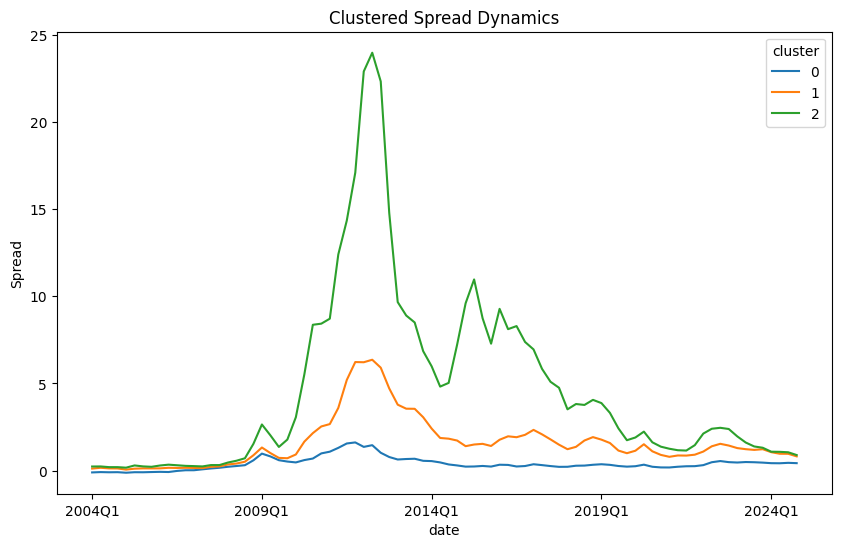

In [ ]:


cluster_means = spread_wide.groupby("cluster").mean().T

cluster_means.plot(figsize=(10,6))
plt.title("Clustered Spread Dynamics")
plt.ylabel("Spread")
plt.show()

In [33]:
spread = df[df["variable"] == "spread"].copy()
spread = spread.rename(columns={"value": "spread"})
debt = df[df["variable"] == "debt_gdp"].copy()
debt = debt.rename(columns={"value": "debt_gdp"})

In [34]:
df_plot = spread.merge(
    debt[["country", "date", "debt_gdp"]],
    on=["country", "date"]
)

In [ ]:
#exklude germany 
df_plot = df_plot[df_plot["country"] != "DE"]

In [37]:

# --- extract spreads ---
spread = df[df["variable"] == "spread"].copy()
spread = spread.rename(columns={"value": "spread"})

# --- extract debt/gdp ---
debt = df[df["variable"] == "debt_gdp"].copy()
debt = debt.rename(columns={"value": "debt_gdp"})

# --- merge datasets ---
df_plot = spread.merge(
    debt[["country", "date", "debt_gdp"]],
    on=["country", "date"]
)

# ensure numeric
df_plot["spread"] = pd.to_numeric(df_plot["spread"], errors="coerce")
df_plot["debt_gdp"] = pd.to_numeric(df_plot["debt_gdp"], errors="coerce")

# --- exclude Germany ---
df_plot = df_plot[df_plot["country"] != "DE"]

# --- create folder if needed ---
os.makedirs("data_out/plots_pdf", exist_ok=True)

# --- save plots ---
with PdfPages("data_out/plots_pdf/DEBT_GDP_RATIO_SPREADS_04_24.pdf") as pdf:

    for country in sorted(df_plot["country"].unique()):

        df_country = df_plot[df_plot["country"] == country]

        plt.figure(figsize=(6,5))

        sns.scatterplot(
            data=df_country,
            x="debt_gdp",
            y="spread",
            alpha=0.7
        )

        # regression line
        sns.regplot(
            data=df_country,
            x="debt_gdp",
            y="spread",
            scatter=False,
            color="red"
        )

        plt.title(f"{country}: Spread vs Debt/GDP")
        plt.xlabel("Debt/GDP")
        plt.ylabel("Spread")

        plt.tight_layout()

        pdf.savefig()
        plt.close()

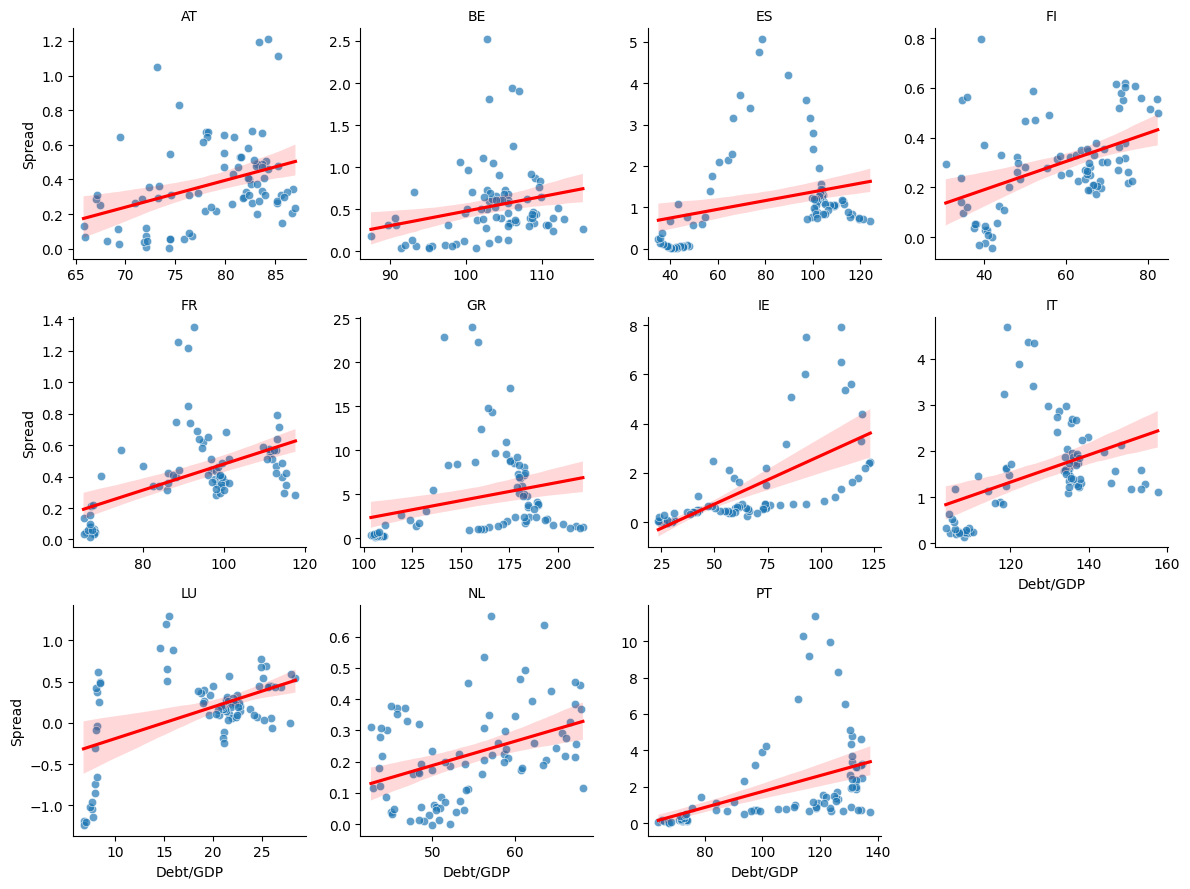

In [40]:
g = sns.FacetGrid(
    df_plot,
    col="country",
    col_wrap=4,
    height=3,
    sharex=False,   # independent x-axis
    sharey=False    # independent y-axis
)

g.map_dataframe(
    sns.scatterplot,
    x="debt_gdp",
    y="spread",
    alpha=0.7
)

g.map_dataframe(
    sns.regplot,
    x="debt_gdp",
    y="spread",
    scatter=False,
    color="red"
)

g.set_axis_labels("Debt/GDP", "Spread")
g.set_titles("{col_name}")

plt.tight_layout()

In [41]:


df_cluster = df_plot.copy()

clusters = []

for country in df_cluster["country"].unique():
    
    df_c = df_cluster[df_cluster["country"] == country].copy()
    
    X = df_c[["debt_gdp","spread"]].dropna()
    
    kmeans = KMeans(n_clusters=3, random_state=42)
    
    df_c.loc[X.index, "cluster"] = kmeans.fit_predict(X)
    
    clusters.append(df_c)

df_cluster = pd.concat(clusters)

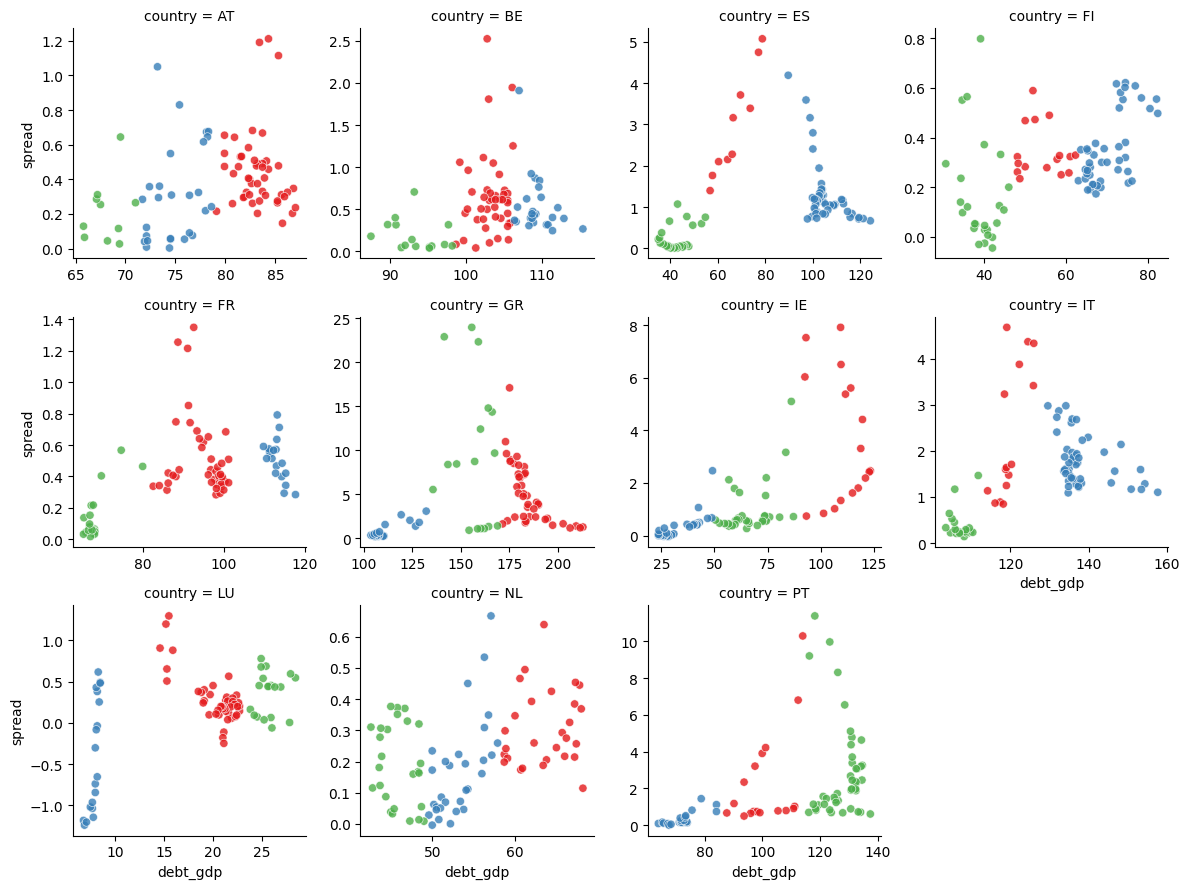

In [42]:
g_2 = sns.FacetGrid(
    df_cluster,
    col="country",
    col_wrap=4,
    height=3,
    sharex=False,
    sharey=False
)

g_2.map_dataframe(
    sns.scatterplot,
    x="debt_gdp",
    y="spread",
    hue="cluster",
    palette="Set1",
    alpha=0.8
)